# 1. How to train your own model and run an experiment

#### 1.0 Overview
This notebook builds a ML model from scratch and covers the complete workflow in four steps:

1. **Configure:** Define the market environment, risk preference and the network architecture.
2. **Train:** Simulate the market environment and train the ML model based on your configuration.
3. **Save and load:** Save the finished model under your desired name and load it into your notebook to run an experiment.
4. **Experiment:** Run an experiment on unseen market scenarios, to evaluate the ML model's performance.

Why this matters: after this notebook you train a Deep-hedging-ML model on any setting of your choice like: different strike, different risk level, different maturity, etc.instead of only replaying the shipped model.

#### 2.0 Configure your own model

The constructor takes three parameter blocks, which you can specify:

| Block | What it controls | Why it matters |
|---|---|---|
| `HestonParameters` | The market: spot, variance dynamics, strike, maturity, time grid | Determines premium $q$ (computed with the COS pricer), start values and all simulated paths |
| `TrainingParameters` | The optimization: CVaR level $\alpha$, Adam settings, number of paths, seeds | Determines what "good hedging" means and how long training takes |
| `DFNNParameters` | The architecture: hidden width, activation, starting value of $w$ | Determines the capacity of the approximation |

Three properties worth knowing:

- **Missing blocks fall back to the paper defaults:** Passing no block (or `None`) gives exactly the specification of the shipped model in Notebook 01. The example below  overrides all three.
- **Input and output dimensions both are fixed at 2:** Each network receives the two features $(\log S_k, V_k)$ and returns the two hedge positions $(\delta^1_k, \delta^2_k)$, this mirrors the two hedging instruments (stock and variance swap) and can not be changed.
- **The runtime scales with `timesteps` × `N_STEPS`:** One network exists per rebalancing date and every gradient step updates **ALL** of them. For a first try, use small values for these parameters (timesteps<30,N_STEPS<100000)check first that everything runs, then later scale up.

**What below example builds:** a market with 15 daily rebalancing dates, a risk-averse CVaR level of $\alpha = 0.9$, with `tanh` activations, hence the model name is `heston_15d_alpha_90`. All values and their typical ranges are documented inline in the code cell.

In [ ]:
from deep_hedging_heston import DeepHedger                                                       # the orchestrating class of the package
from deep_hedging_heston.parameters import HestonParameters, TrainingParameters, DFNNParameters  # the three parameter blocks for a custom model must be imported

dh_custom = DeepHedger(
    heston_parameters=HestonParameters(
        v0=0.05,                # initial stock variance, higher = more volatile market (typical: 0.01-0.09, must be positive)
        S0=120,                 # initial stock price (typical: 100, must be positive)
        K=105,                  # strike of the call (typical: around S0, must be positive)
        T=15/365,               # maturity in years: 15 days here (typical: 15/365 to 90/365, must be positive)
        timesteps=15,           # nr of daily rebalancing dates (keep 15-90)
        rho=-0.5,               # correlation stock/variance, negative means vola rises when stock falls (typical: -0.7 to -0.3, must be in [-1,1])
        kappa=1.5,              # mean-reversion speed of the variance; higher = variance pulled faster back to theta (typical: 0.5-3, must be positive)
        theta=0.05,             # long-run variance level by which the variance reverts to (typical: 0.02-0.06, must be positive)
        xi=1.8                  # vola-of-vola, how variance itself fluctuates, higher gives more extreme vola moves (typical: 1-3, must be positive)
        ),

    training_parameters=TrainingParameters(
        ALPHA=0.9,              # CVaR risk level, by which ML model minimizes avg-loss across worst (1-ALPHA) of paths (0.5 = mild, 0.9 = risk-averse, must be in (0,1))
        LEARNING_RATE=0.005,    # step size for Adam optimizer, too high = unstable loss, too low = slow training (typical: 0.001- 0.005 or lower, must be positive)
        BATCH=256,              # nr of paths per gradient step, larger gives smoother gradients but fewer steps per epoch (typical: 256-512, must be positive & below paths)
        N_STEPS=200_000,        # nr of gradient steps, each step drawing a random mini-batch of 256 from paths to update the DFNNs (typical: 20k - 200k, must be positive)        
        PRINT_EVERY=10_000,     # how often training performance (J(Batch), J(val), w) is printed to watch progress (typical: 20% of N_STEPS, must divide evenly into N_STEPS for clean log points)
        paths=50_000,           # nr of simulated market scenarios model learns from (training & validation), more is better (typical: 50k-100k, must be positive and above BATCH)
        paths_test=200_000,     # nr of out-of-sample paths for the final evaluation, NOT used for training or validation (typical: 200k-1M, must be positive)
        seed_train=101,         # seed for the training paths, change it to train on different data (must be integer>0)
        seed_val=202,           # seed for the validation paths, change it to get a different J(val) curve (must be integer>0)
        seed_test=303,          # seed for the out-of-sample test paths, change it to evaluate on different unseen data (must be integer>0)
        seed_tf=7               # TensorFlow seed for random network initialization, change it to get a different starting point of the training (must be integer>0)
        ),

    dfnn_parameters=DFNNParameters(
        nr_of_units=17,         # width of the two hidden layers, larger gives more capacity, but training slower (typical:17 = paper default, must be positive integer)
        activation='tanh',      # activation function for hidden layers, 'relu' is paper default (typical: relu, sigmoid, tanh)
        oce_threshold_start=0.0 # starting value of the trainable OCE threshold w for the loss function, (typical: 0.0, any real number works since w is trained)
        ))

#### 2.1 Train the model

`run()` takes no arguments: all settings come from the parameter blocks in the constructor above. The method executes the new training in following order:

1. **Simulate** training and validation paths based on configured seeds (exact CIR sampling for variance, simplified Broadie-Kaya for stock), as specified in `01_load_the_basemodel_and_start_experiment.ipynb`. 
2. **Train** the model for `N_STEPS` gradient steps: each step draws a random mini-batch of `BATCH` paths to update the DFNNs and threshold $w$ by Adam optimizer, such that the loss (OCE representation of CVaR) $$J \;=\; w \;+\; \frac{1}{1-\alpha}\,\mathbb{E}\!\left[\max\!\left(L - w,\, 0\right)\right]$$ with losses $L = -\varepsilon$ and terminal hedging error $\varepsilon = q - Z + (\delta \cdot S)_T$ is minimized. For every `PRINT_EVERY` step, $J$ is additionally measured on the full validation set to form the learning curve.
3. **Test on unseen data:** After training, out-of-sample (OOS) paths are simulated, which the model has not seen. Metrics on these paths (not on training data!) are the honest measure of hedging quality.
4. **Report:** Metrics are provided to highlight the performance of validation, OOS and the ML model against the analytical benchmark.
**Report:** Three evaluations for the validation data, the OOS checks and the ML hedge are provided.

**How to read the report:**

- **$J^*$ versus sorted CVaR:** two independent definitions of the same quantity. If they
  are close, the loss computation is consistent.
- **$w$ versus VaR:** at the optimum, $w$ sits at the $\text{VaR}_\alpha$ level of the
  losses. A clear gap signals a problem.
- **$p_0 = q + J^*$:** the risk-adjusted indifference price. It is never below $q$
  (Proposition 3.10(ii) of the paper, since the market is a martingale under $\mathbb{Q}$);
  a higher $\alpha$ produces a higher markup.

Why this matters: these three checks tell you whether training is sufficient **before** you rely on the ML model.

In [ ]:
results = dh_custom.run()  # train the model (with above parameters); outputs metrics on validation data, out-of-sample test data and the analytical benchmark

Step      1/30000   J(Batch) =  21.4927   J(val) =  20.8827   w =  0.0050   (  0.1min)
Step   5000/30000   J(Batch) =   0.2809   J(val) =   0.5988   w =  0.2016   (  0.5min)
Step  10000/30000   J(Batch) =   0.4351   J(val) =   0.6330   w =  0.1805   (  0.9min)
Step  15000/30000   J(Batch) =   0.1936   J(val) =   0.5841   w =  0.1641   (  1.3min)
Step  20000/30000   J(Batch) =   0.3053   J(val) =   0.5587   w =  0.1601   (  1.6min)
Step  25000/30000   J(Batch) =   0.2698   J(val) =   0.6399   w =  0.1651   (  2.0min)
Step  30000/30000   J(Batch) =   0.3316   J(val) =   0.5948   w =  0.1598   (  2.3min)


2026-10-04 01:55:16.519867: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-10-04 01:55:25.359251: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-10-04 01:55:42.998473: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Training done in 3.1 min — BatchNorm calibrated.
[val] mean = -0.0010 | std = 0.3015 | J* = 0.3195 | sorted CVaR = 0.3193 | w = 0.1598 vs VaR = 0.1561 | p0 = 15.3844
[OOS] mean = -0.0011 | std = 0.3036 | J* = 0.3200 | sorted CVaR = 0.3197 | w = 0.1598 vs VaR = 0.1556 | p0 = 15.3849
[val Deep Hedge] mean = -0.0010 | std = 0.3015 | J* = 0.3195 | sorted CVaR = 0.3193 | w = 0.1598 vs VaR = 0.1561 | p0 = 15.3844
[val Model Hedge] mean = -0.0008 | std = 0.2231 | CVaR_0.9 = 0.3300


{'premium': 15.06490281704512,
 'result_val': {'name': 'val',
  'mean_error': -0.0009518568986095488,
  'std_error': 0.3014865219593048,
  'J_star': 0.3195107579231262,
  'sorted_cvar': 0.3193427622318268,
  'oce_threshold': 0.15976254642009735,
  'var_quantile': 0.15606185793876648,
  'p0': 15.38441401720047,
  'hedge_errors': array([-0.00016093,  0.06811094, -0.11940098, ..., -0.02394158,
         -0.13893306, -0.05337906], dtype=float32)},
 'result_oos': {'name': 'OOS',
  'mean_error': -0.0010552360909059644,
  'std_error': 0.3035530149936676,
  'J_star': 0.3199925422668457,
  'sorted_cvar': 0.31974121928215027,
  'oce_threshold': 0.15976254642009735,
  'var_quantile': 0.15559592843055725,
  'p0': 15.38489580154419,
  'hedge_errors': array([ 0.05444431,  0.63788795, -0.09681034, ...,  1.4092846 ,
         -0.10599756, -0.16404343], dtype=float32)},
 'deep_result': {'name': 'val Deep Hedge',
  'mean_error': -0.0009518568986095488,
  'std_error': 0.3014865219593048,
  'J_star': 0.3195

#### 2.2 Save the model

The command `dh_custom.save_model("folderpath", "ml_model_name")` writes three files into the defined folder. It takes two arguments, the `folderpath` the location to store the model and `ml_model_name` the name of the files, where the convention is `heston_xd_alpha_y` and `x` for the nr of days and `y` for the used alpha CVaR level

In [13]:
dh_custom.save_model("ml_models", "heston_15d_alpha_90")  # save trained model to folder ml_models/ under the chosen name; convention is 'heston_marketdays_cvarlevel'

#### 3.0 Load the model

Before using a ML model, you must load it via `DeepHedger.load_model("folderpath", "ml_model_name")`. The command reads the saved ML model and makes it ready-to-use inside your jupyter notebook. It takes the same two arguments as in `save_model`.

In [ ]:
my_custom_model = DeepHedger.load_model("ml_models", "heston_15d_alpha_90")  # load the saved model 'heston_15d_alpha_90' from folder ml_models/ 

#### 4.0 Run an experiment

The command `my_custom_model.experiment(seed)` simulates one unseen market scenario and hedges it twice, once with the ML model and once with the analytical benchmark. It then plots the simulated stock and variance paths, as well as the performances of both approaches for hedging, PnL, portfolio and terminal error. Also learning curves for training and vaildation are plotted. The command takes the argument `seed`, a non-negative integer, that selects the market scenario: the same seed reproduces the same scenario, a new seed generates a new one. Try several seeds to see if the hedge stays close to the analytical benchmark.

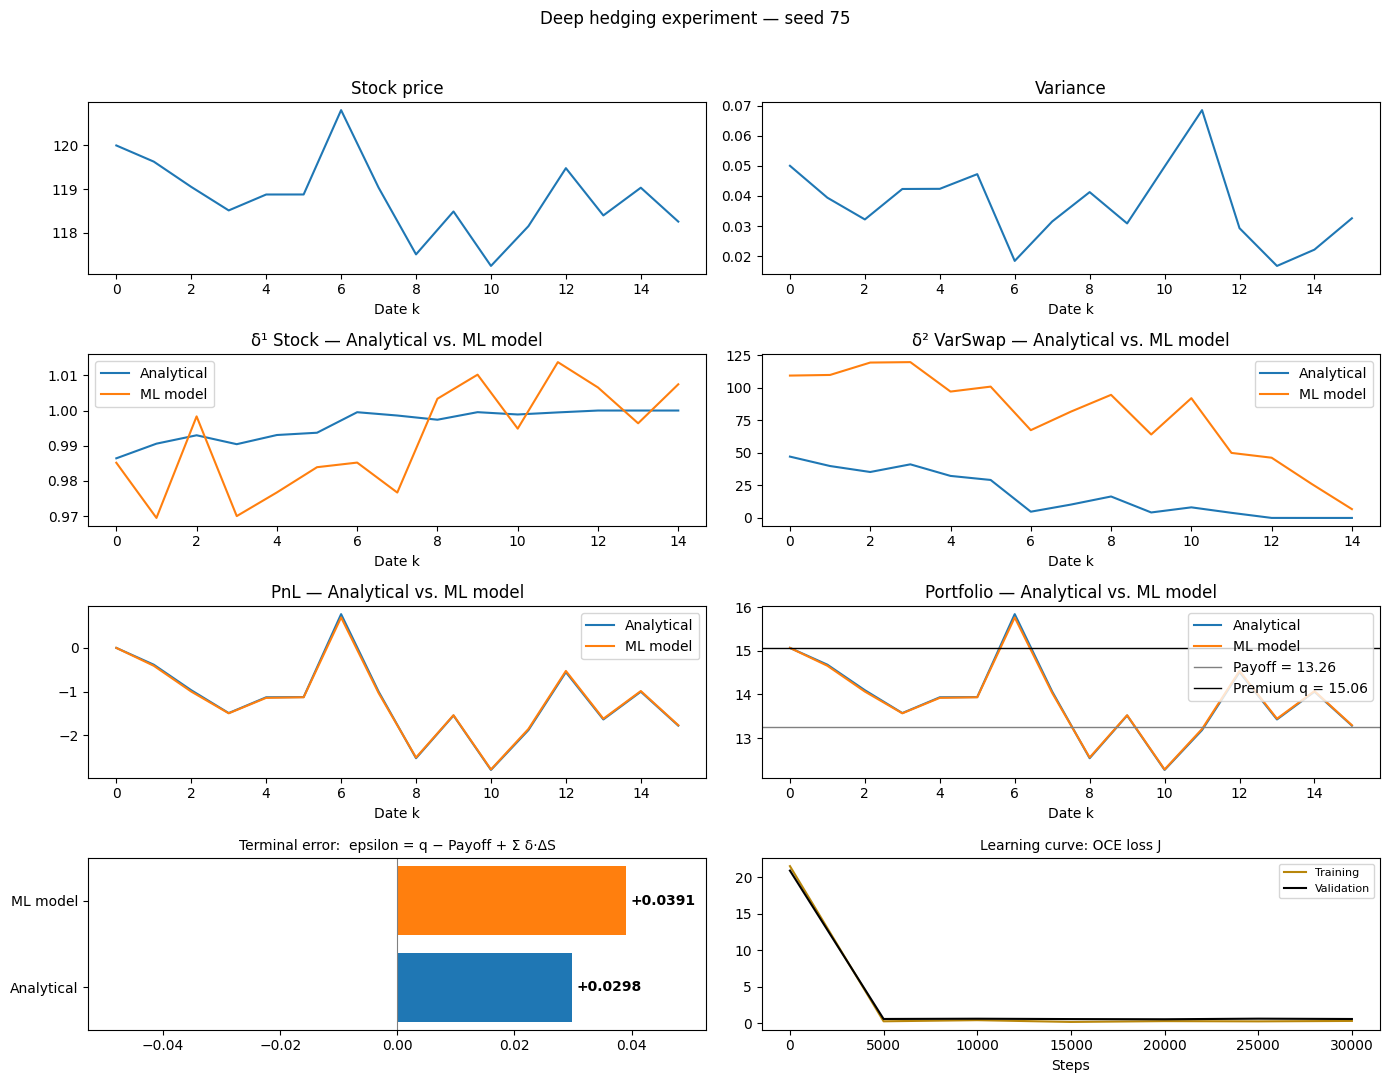

Terminal error — formula: +0.0298 | ML model: +0.0391


{'figure': <Figure size 1400x1100 with 8 Axes>,
 'eps_formula': 0.029801518767772706,
 'eps_ml': 0.03909789620297133}

In [ ]:
my_custom_model.experiment(seed=75)  # run an experiment on an unseen market path